In [3]:
from google.colab import files
uploaded = files.upload()

Saving Fake.csv to Fake.csv
Saving True.csv to True.csv


In [11]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("1. Loading raw datasets (Skipping bad lines)...")
fake_df = pd.read_csv('Fake.csv', on_bad_lines='skip', engine='python')
true_df = pd.read_csv('True.csv', on_bad_lines='skip', engine='python')

true_df['label'] = 1
fake_df['label'] = 0

print("2. Merging and Cleaning...")
combined_df = pd.concat([true_df, fake_df], ignore_index=True)
combined_df['cleaned_text'] = combined_df['text'].apply(clean_text)

# Drop any rows where cleaning left empty strings
combined_df = combined_df.dropna(subset=['cleaned_text'])

# Split the data (80% Training, 20% Testing)
X = combined_df['cleaned_text']
y = combined_df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data ready! Training samples: {len(X_train)} | Testing samples: {len(X_test)}")

1. Loading raw datasets (Skipping bad lines)...
2. Merging and Cleaning...
Data ready! Training samples: 35918 | Testing samples: 8980


1. Vectorizing text using TF-IDF...
2. Training Random Forest model... (This may take a minute)
3. Generating Evaluation Metrics...

--- Random Forest Evaluation ---
Accuracy:  0.9963

Classification Report:
              precision    recall  f1-score   support

    Fake (0)       1.00      1.00      1.00      4650
    Real (1)       1.00      1.00      1.00      4330

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



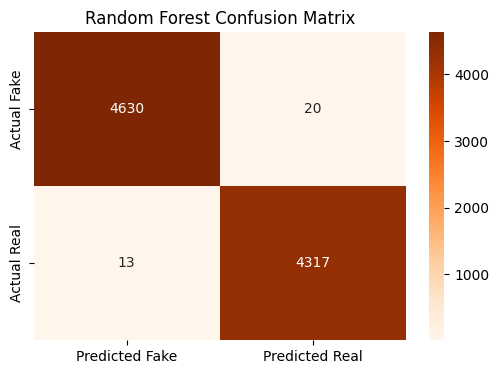

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("1. Vectorizing text using TF-IDF...")
tfidf_vectorizer = TfidfVectorizer(max_features=10000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("2. Training Random Forest model... (This may take a minute)")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_tfidf, y_train)

print("3. Generating Evaluation Metrics...\n")
y_pred_rf = rf_model.predict(X_test_tfidf)

print("--- Random Forest Evaluation ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Fake (0)', 'Real (1)']))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Predicted Fake', 'Predicted Real'],
            yticklabels=['Actual Fake', 'Actual Real'])
plt.title('Random Forest Confusion Matrix')
plt.show()